In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/andonians/random-linear-regression/train.csv
/kaggle/input/datasets/andonians/random-linear-regression/test.csv


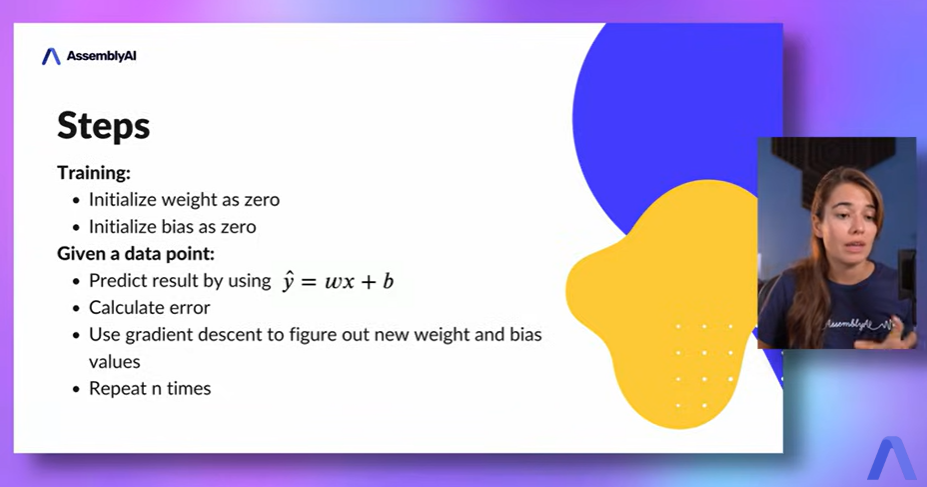

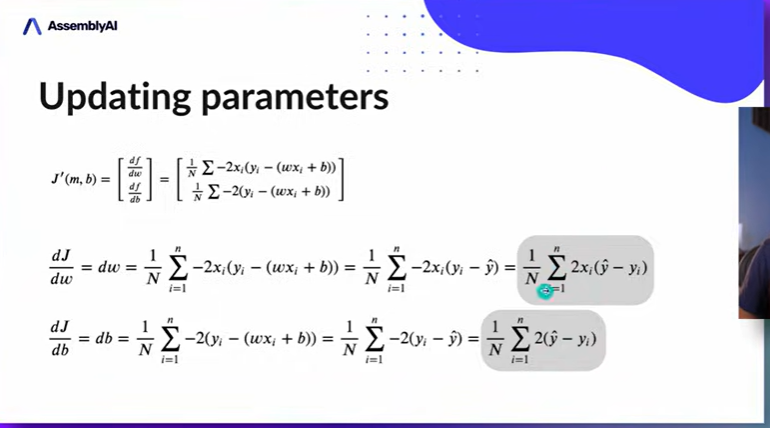

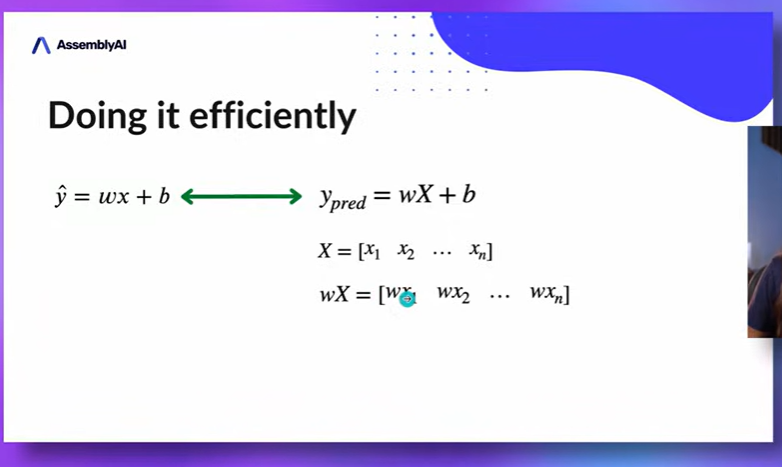

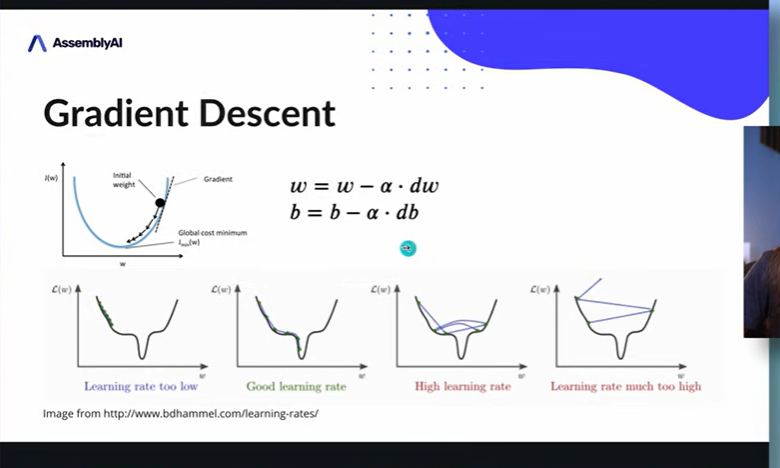

In [4]:
#Linear regression from scratch 
import numpy as np

class LinearRegression:
    def __init__(self, lr= 0.001, n_iterations =1000):
        self.lr = lr
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for _ in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias
    
            dw = (1/ n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred-y)

            self.weights = self.weights -self.lr * dw 
            self.bias = self.bias - self.lr * db 
        return self
        
    def predict(self, X):    
        y_pred = np.dot(X, self.weights) + self.bias
        return y_pred

In [5]:
model = LinearRegression()

In [6]:
from sklearn.model_selection import train_test_split 
import pandas as pd

df = {
    "X": [0] * 30,
    "y": [0] * 30
}



In [7]:
data = pd.DataFrame(df)
data.head()

,X,y
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [8]:
for i in range(len(data["X"])):
    data.loc[i,"X"] = data.loc[i, "X"] + (i^3) + 6
    data.loc[i,"y"] = data.loc[i, "y" ]+ (i^2) + 6

In [9]:
df2 = data.copy()

In [10]:
df2[:-1]

,X,y
0,9,8
1,8,9
2,7,6
3,6,7
4,13,12
5,12,13
6,11,10
7,10,11
8,17,16
9,16,17


In [11]:
X = df2.drop("y", axis =1)
y = df2.pop("y")

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state =42)


In [14]:
print(X_train.shape)

print(y_train.shape)

(21, 1)
(21,)


In [15]:
model.fit(X_train, y_train)

In [16]:
preds = model.predict(X_test)

In [30]:
def rmse(y_test, preds):
    rsme= np.sqrt(np.mean((y_test - preds) ** 2))
    return rsme
    

In [31]:
rmse = rmse(y_test, preds)
print(rmse)

1.0009422282501665


In [26]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(X_train, y_train)

y_preds = reg.predict(X_test)

rmse = rmse(y_test, y_preds)
print(rmse)

1.0050561456867673


In [33]:
print("Sklearn's coeffient/ weight:",reg.coef_)
print("my model's weight/coefficient", model.weights)

print("Sklearn's bias", reg.intercept_)
print("My model's bias", model.bias)

Sklearn's coeffient/ weight: [0.99877744]
my model's weight/coefficient [0.99636518]
Sklearn's bias -0.02450680744651379
My model's bias 0.03148624843442018


In [20]:
import matplotlib.pyplot as plt

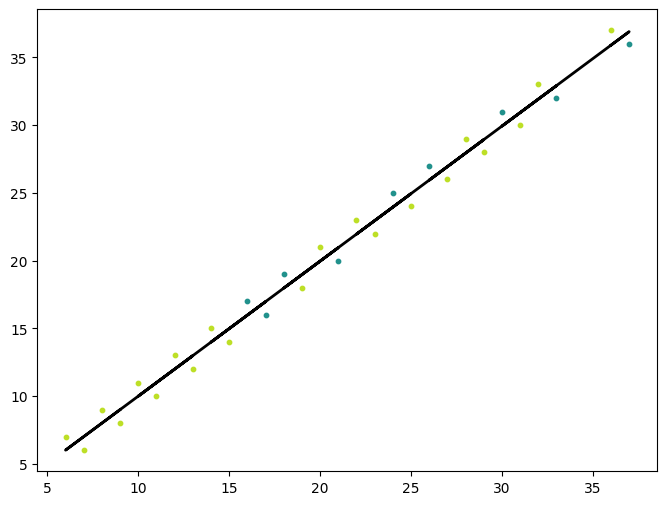

In [21]:
y_pred_line = model.predict(X)

cmap = plt.get_cmap("viridis")

fig = plt.figure(figsize=(8,6))

m1 = plt.scatter(X_train, y_train, color = cmap(0.9), s=10)

m2 = plt.scatter(X_test, y_test, color= cmap(0.5), s = 10)

plt.plot(X, y_pred_line, color = "black", linewidth =2, label = "Predictions")

plt.show()